In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

models = [
    "Árbol de decisión",
    "KNN (k=11)",
    "Naive Bayes (Gaussian)",
    "Naive Bayes (Multinomial)",
    "Random Forest",
    "Regresión logística",
    "SVM",
    "XGBoost",
]

metrics_mean = pd.DataFrame({
    "Modelo": models,
    "Accuracy": [0.8966, 0.8898, 0.8557, 0.7511, 0.9182, 0.9000, 0.8784, 0.9057],
    "Precision": [0.8215, 0.8130, 0.6288, 0.4759, 0.8478, 0.8368, 0.6632, 0.7969],
    "Recall": [0.7173, 0.6700, 0.8880, 0.9717, 0.7775, 0.6948,  0.9200, 0.7838],
    "F1-score": [0.7536, 0.7300, 0.7347, 0.6359, 0.8083, 0.7553, 0.7681, 0.7887],
    "AUC": [0.9324, 0.9468, 0.9537, 0.8441, 0.9630, 0.9571, 0.9629, 0.9619],
})

metrics_std = pd.DataFrame({
    "Modelo": models,
    "Accuracy": [0.0285, 0.0301, 0.0380, 0.0430, 0.0304, 0.0232, 0.0269, 0.0249],
    "Precision": [0.1060, 0.0692, 0.0681, 0.0727, 0.0819, 0.0623, 0.0794, 0.0631],
    "Recall": [0.1141, 0.1145, 0.0411, 0.0464, 0.0841, 0.0862, 0.0763, 0.0554],
    "F1-score": [0.0630, 0.0854, 0.0555, 0.0694, 0.0674, 0.0597, 0.0684, 0.0475],
    "AUC": [0.0181, 0.0228, 0.0132, 0.0293, 0.0150, 0.0101, 0.0156, 0.0129],
})


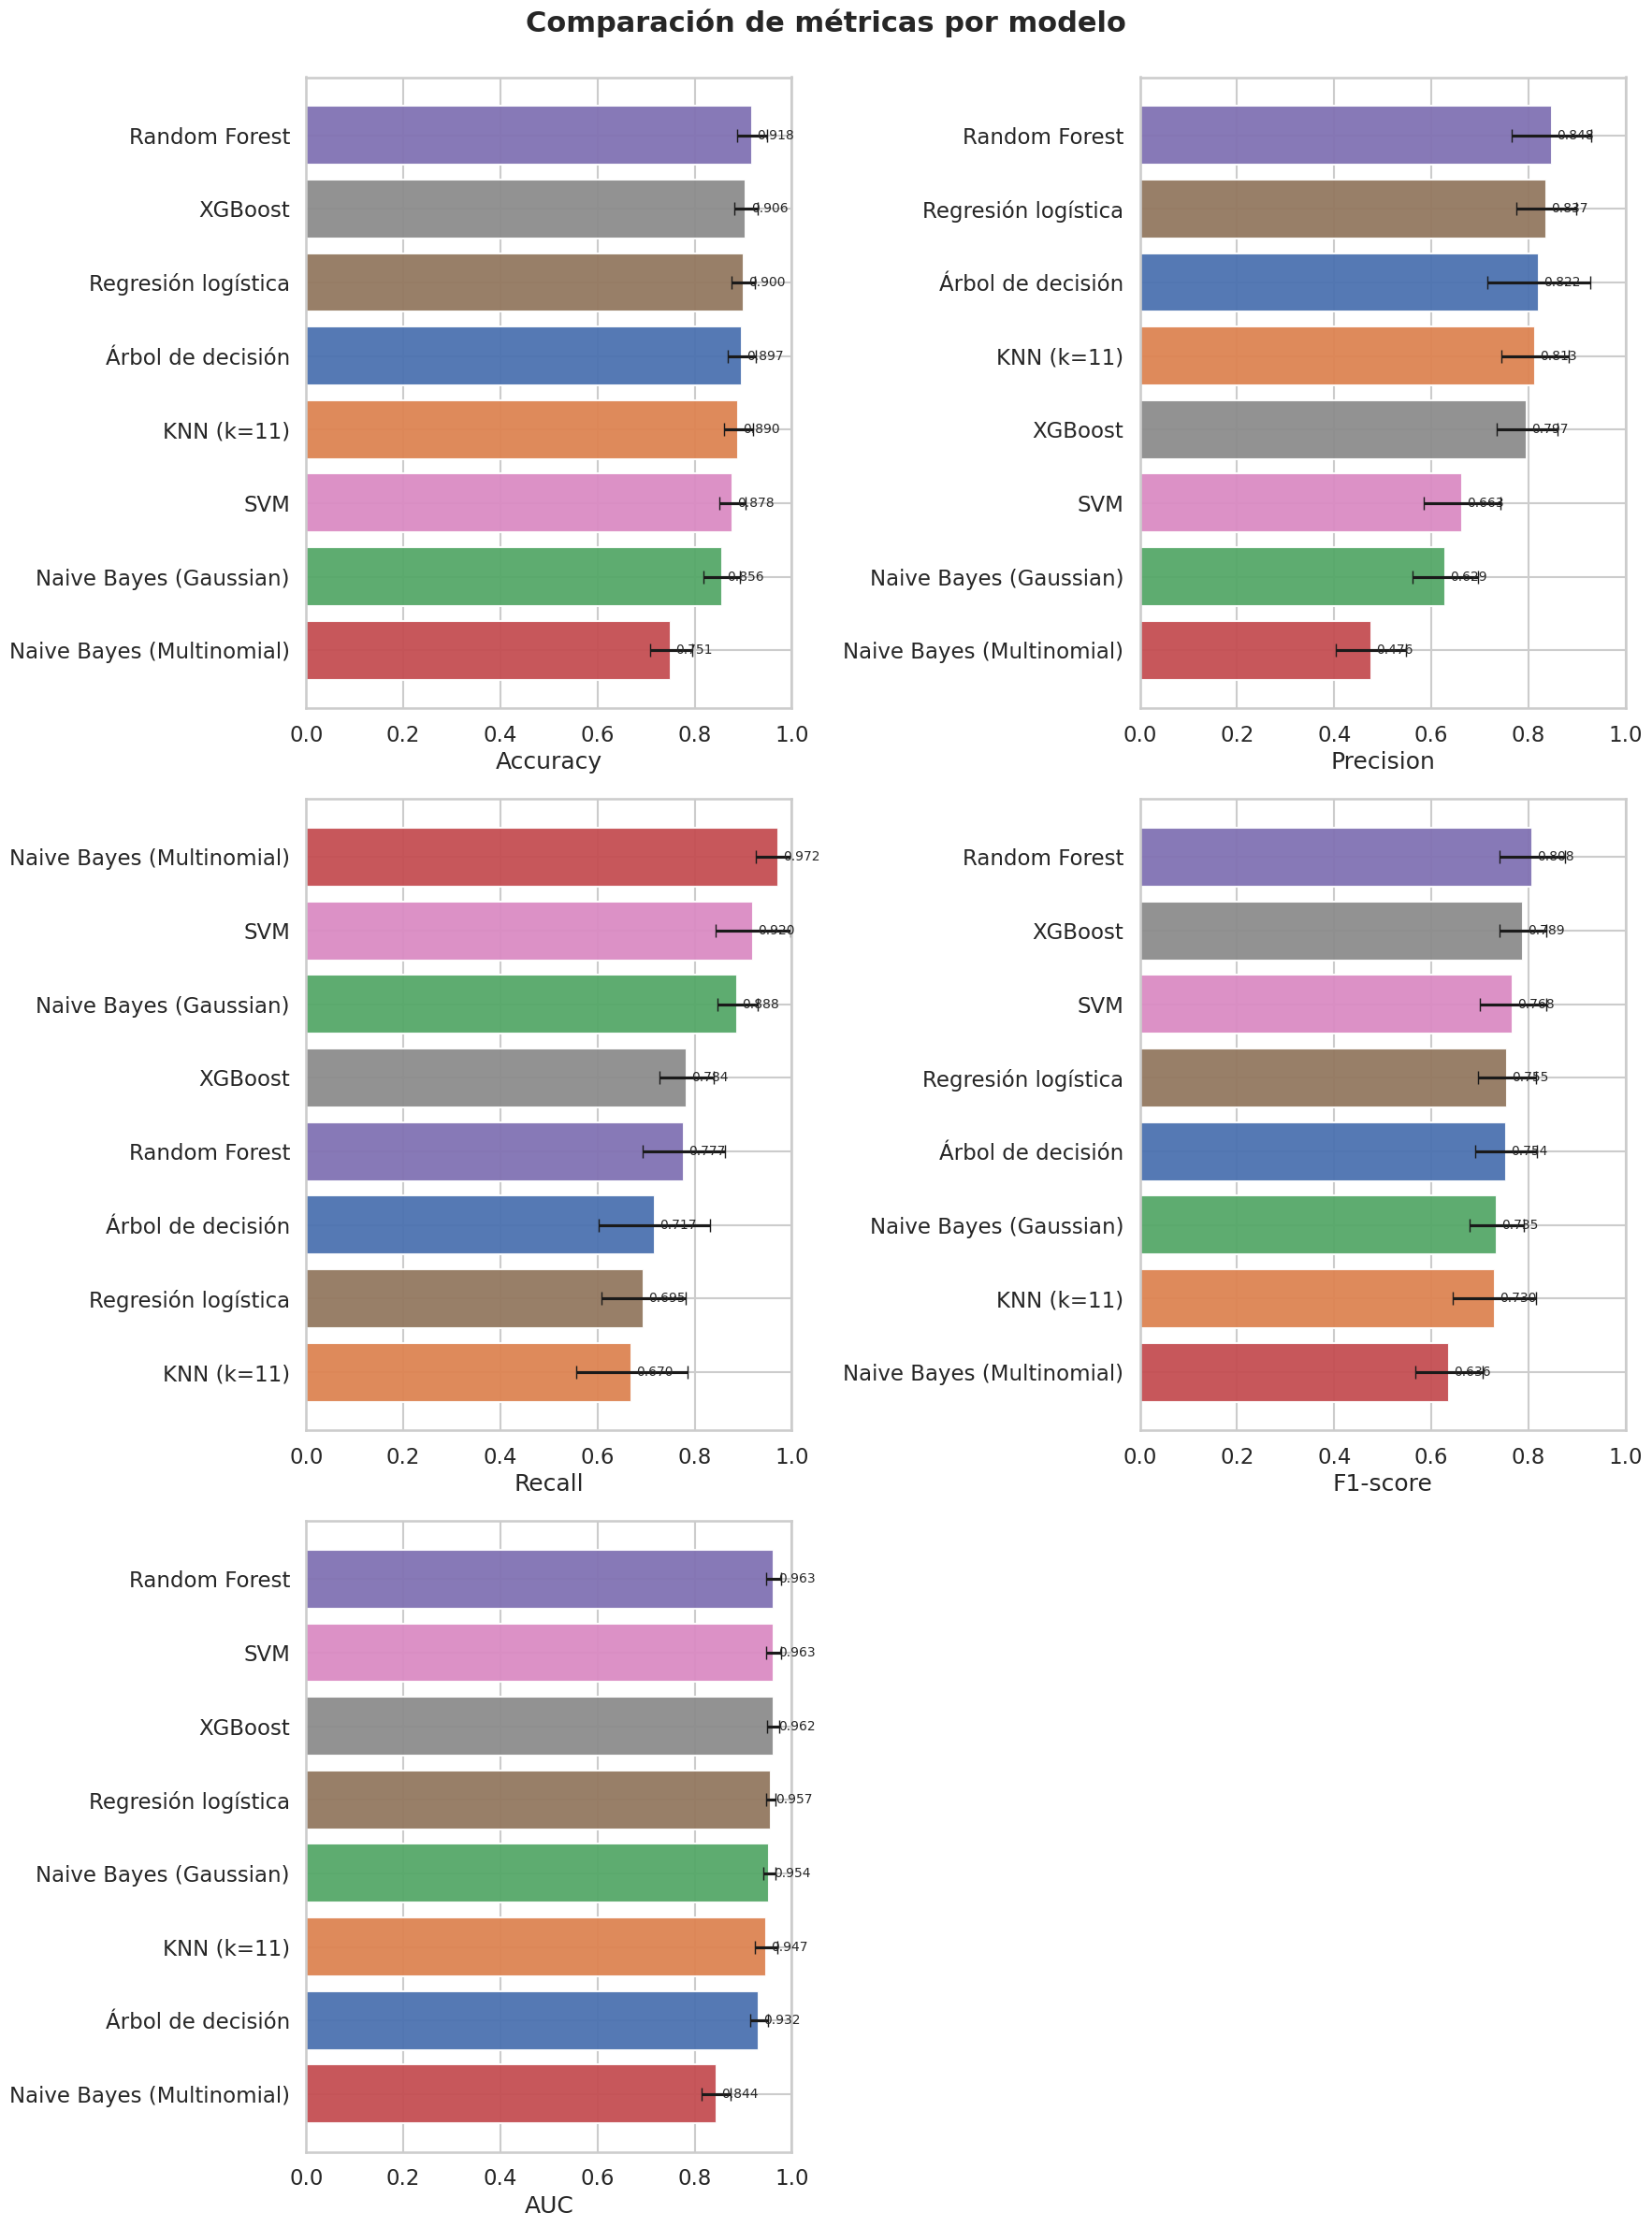

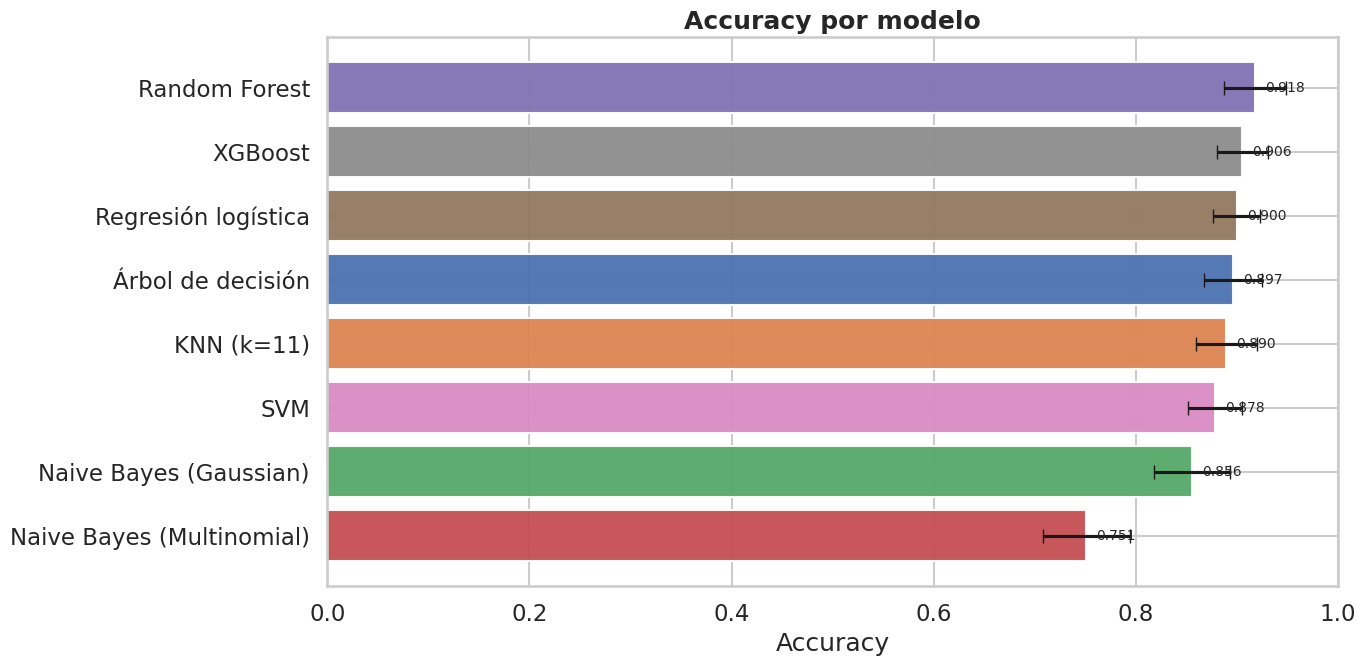

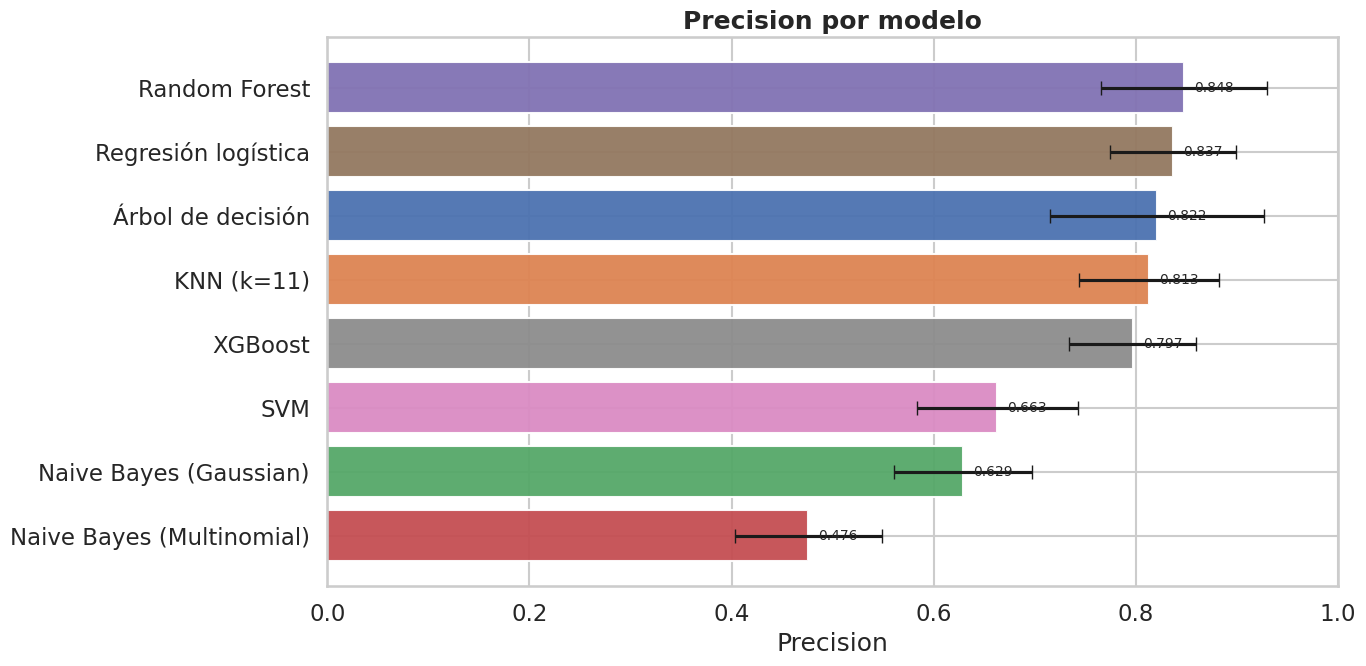

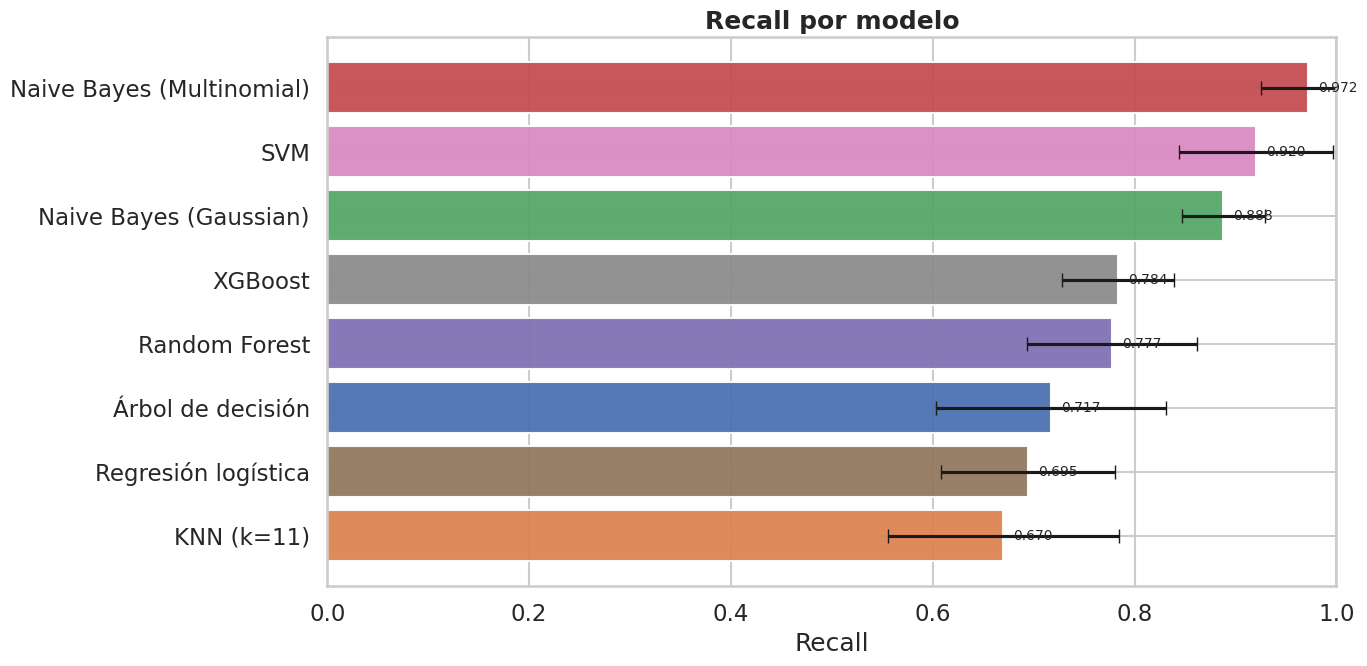

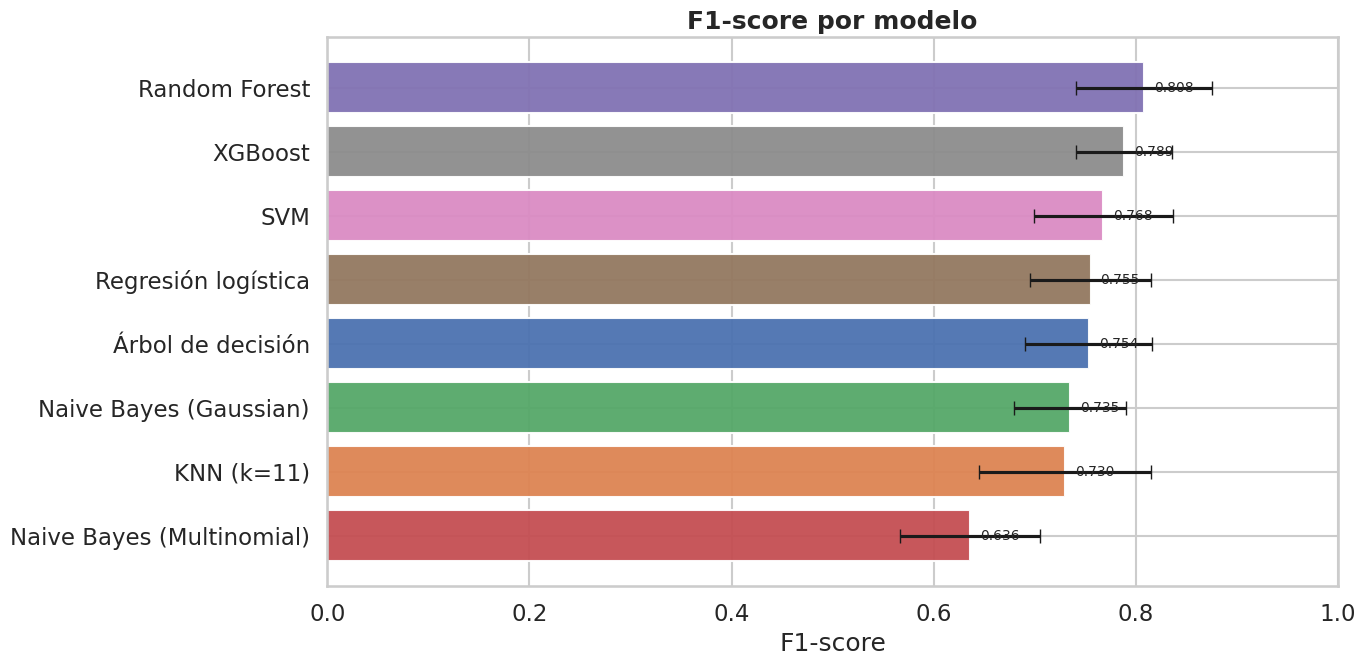

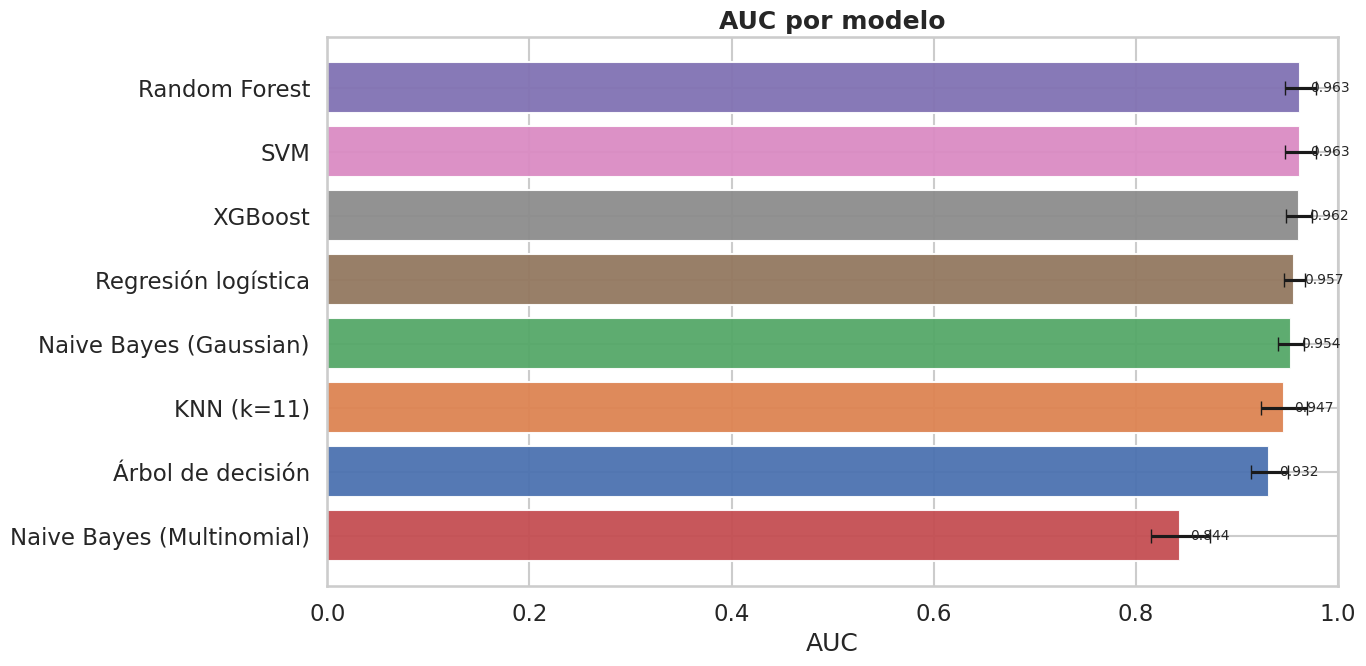

In [21]:
metric_order = ["Accuracy", "Precision", "Recall", "F1-score", "AUC"]
palette = sns.color_palette("deep", n_colors=len(models))

model_colors = {model_name: color for model_name, color in zip(metrics_mean["Modelo"].unique(), palette)}

fig, axes = plt.subplots(3, 2, figsize=(18, 24))
axes = axes.flatten()

for idx, metric in enumerate(metric_order):
    ax = axes[idx]
    plot_df = metrics_mean.sort_values(metric, ascending=True)
    plot_std = metrics_std.set_index("Modelo").loc[plot_df["Modelo"]][metric].values

    current_colors = [model_colors[m] for m in plot_df["Modelo"]]

    bars = ax.barh(plot_df["Modelo"], plot_df[metric], xerr=plot_std, color=current_colors, capsize=5, alpha=0.95)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel(metric)
    ax.set_ylabel("")
    for bar in bars:
        value = bar.get_width()
        ax.text(value + 0.01, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", fontsize=10)

axes[-1].axis("off")
fig.suptitle("Comparación de métricas por modelo", fontsize=22, weight="bold", y=0.995)
plt.tight_layout()
plt.show()

for metric in metric_order:
    plot_df = metrics_mean.sort_values(metric, ascending=True)
    plot_std = metrics_std.set_index("Modelo").loc[plot_df["Modelo"]][metric].values
    current_colors = [model_colors[m] for m in plot_df["Modelo"]]
    
    plt.figure(figsize=(14, 7))
    bars = plt.barh(plot_df["Modelo"], plot_df[metric], xerr=plot_std, color=current_colors, capsize=5, alpha=0.95)
    plt.title(f"{metric} por modelo", weight="bold")
    plt.xlim(0, 1.0)
    plt.xlabel(metric)
    plt.ylabel("")
    for bar in bars:
        value = bar.get_width()
        plt.text(value + 0.01, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", fontsize=10)
    plt.tight_layout()
    plt.show()